# Sprint 14
## Predicción de cancelación y segmentación de clientes para Model Fitness
### DA: *Mau Vilar* 
#### https://github.com/mauvilar

**Objetivo general:**

- Predecir la probabilidad de cancelación (churn) para el próximo mes.
- Crear clústeres de clientes para entender perfiles típicos.
- Formular recomendaciones para mejorar la retención de clientes.

In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage

## EDA

In [56]:
df = pd.read_csv('/datasets/gym_churn_us.csv')

In [58]:
print("\n=== shape ===")
print(df.shape)

print("\n=== info ===")
print(df.info())

print("\n=== describe ===")
print(df.describe())




=== shape ===
(4000, 14)

=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_freque

In [60]:
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


## Descripción de los datos

- `Churn` – 1 si el cliente canceló en el mes analizado, 0 si no canceló.
- `gender` – género del cliente.
- `Near_Location` – 1 si vive/trabaja cerca del gimnasio.
- `Partner` – 1 si trabaja en una empresa asociada al gimnasio.
- `Promo_friends` – 1 si llegó por una promo “trae a un amigo”.
- `Phone` – 1 si dejó su número de teléfono.
- `Age` – edad del cliente.
- `Lifetime` – tiempo en meses desde que llegó al gimnasio.

**Registro de membresía, visitas y compras**

- `Contract_period` – duración del contrato (1, 3, 6 o 12 meses).
- `Month_to_end_contract` – meses restantes del contrato actual.
- `Group_visits` – 1 si asiste a clases grupales.
- `Avg_class_frequency_total` – visitas promedio por semana a lo largo de toda su vida como cliente.
- `Avg_class_frequency_current_month` – visitas promedio por semana en el mes actual.
- `Avg_additional_charges_total` – gasto total en servicios adicionales (cafetería, productos, masajes, etc.).


#### Datos nulos y duplicados

In [66]:
print("\n=== valores ausentes por columna ===")
print(df.isna().sum())

print("\n=== número de filas duplicadas ===")
print(df.duplicated().sum())


=== valores ausentes por columna ===
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

=== número de filas duplicadas ===
0


In [67]:
churn_mean = df.groupby('Churn').mean().T

print("\n=== medias de las características por churn (transpuesta) ===")
churn_mean



=== medias de las características por churn (transpuesta) ===


Churn,0,1
gender,0.510037,0.510839
Near_Location,0.873086,0.768143
Partner,0.534195,0.355325
Promo_friends,0.353522,0.183789
Phone,0.903709,0.902922
Contract_period,5.747193,1.728558
Group_visits,0.464103,0.268615
Age,29.976523,26.989632
Avg_additional_charges_total,158.445715,115.082899
Month_to_end_contract,5.283089,1.662582


In [68]:
print("\n=== distribución de la variable objetivo Churn (conteo) ===")
print(df['Churn'].value_counts())

print("\n=== distribución de la variable objetivo Churn (proporción) ===")
print(df['Churn'].value_counts(normalize=True))



=== distribución de la variable objetivo Churn (conteo) ===
0    2939
1    1061
Name: Churn, dtype: int64

=== distribución de la variable objetivo Churn (proporción) ===
0    0.73475
1    0.26525
Name: Churn, dtype: float64


A partir de la tabla de medias por grupo de `Churn` se observa que, en promedio:

- Las personas que **no cancelan** (`Churn = 0`) tienden a:
  - vivir o trabajar más cerca del gimnasio (`Near_Location` más alto)
  - trabajar con más frecuencia en empresas asociadas (`Partner` más alto)
  - haber llegado con promociones de amigos en mayor proporción (`Promo_friends` más alto)
  - tener contratos más largos (`Contract_period` y `Month_to_end_contract` más altos)
  - asistir más a clases grupales (`Group_visits` más alto)
  - llevar más tiempo en el gimnasio (`Lifetime` más alto)
  - visitar el gimnasio con mayor frecuencia (`Avg_class_frequency_total` y `Avg_class_frequency_current_month` más altos)
  - gastar más en servicios adicionales (`Avg_additional_charges_total` más alto)

En cambio, los clientes que **sí cancelan** (`Churn = 1`) suelen tener contratos más cortos, menor frecuencia de visitas y un historial más corto en el gimnasio.


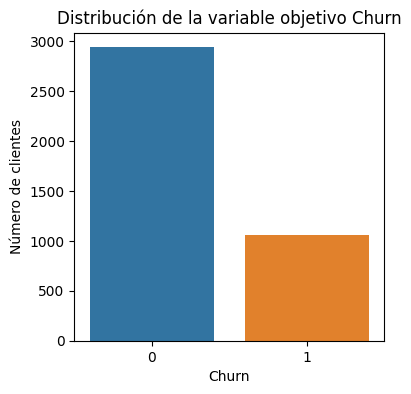

In [69]:
plt.figure(figsize=(4, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribución de la variable objetivo Churn')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.show()


### Distribuciones por churn para algunas variables clave


=== distribución de Age por churn ===


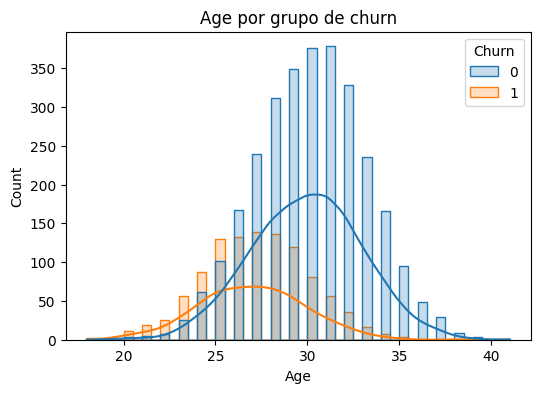


=== distribución de Lifetime por churn ===


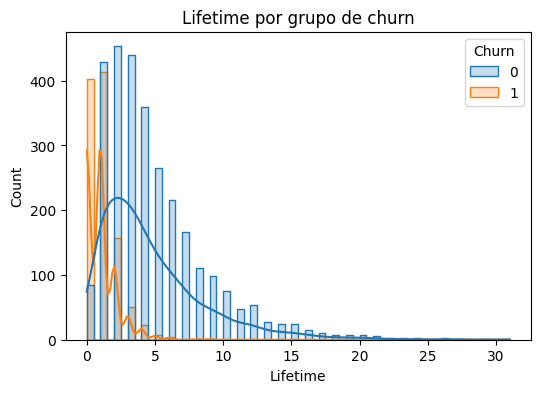


=== distribución de Avg_class_frequency_total por churn ===


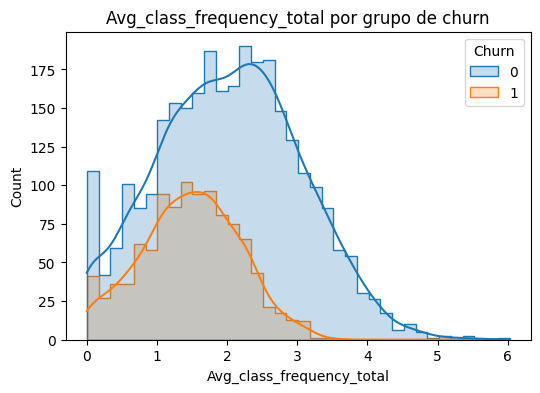


=== distribución de Avg_class_frequency_current_month por churn ===


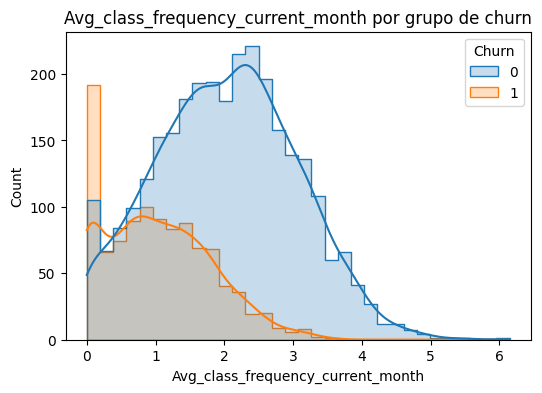


=== distribución de Avg_additional_charges_total por churn ===


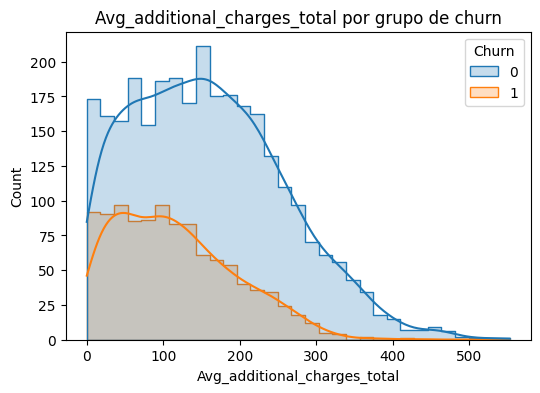

In [71]:
cols = [
    'Age',
    'Lifetime',
    'Avg_class_frequency_total',
    'Avg_class_frequency_current_month',
    'Avg_additional_charges_total'
]

for col in cols:
    print(f"\n=== distribución de {col} por churn ===")
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='Churn', kde=True, element='step')
    plt.title(f'{col} por grupo de churn')
    plt.show()


### Matriz de correlación

In [73]:
print("\n=== matriz de correlación ===")
corr = df.corr()
corr



=== matriz de correlación ===


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
Near_Location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
Partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
Promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
Phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
Contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
Group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
Age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
Avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
Month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


In [86]:
print("\n=== correlación de cada variable con Churn ===")
print(corr['Churn'].sort_values(ascending=False))
print("\n=== cuanto más alto el valor de esa característica, MENOS probable que el cliente cancele==")


=== correlación de cada variable con Churn ===
Churn                                1.000000
gender                               0.000708
Phone                               -0.001177
Near_Location                       -0.128098
Partner                             -0.157986
Promo_friends                       -0.162233
Group_visits                        -0.175325
Avg_additional_charges_total        -0.198697
Avg_class_frequency_total           -0.249715
Month_to_end_contract               -0.381393
Contract_period                     -0.389984
Age                                 -0.404735
Avg_class_frequency_current_month   -0.412348
Lifetime                            -0.438220
Name: Churn, dtype: float64

=== cuanto más alto el valor de esa característica, MENOS probable que el cliente cancele==


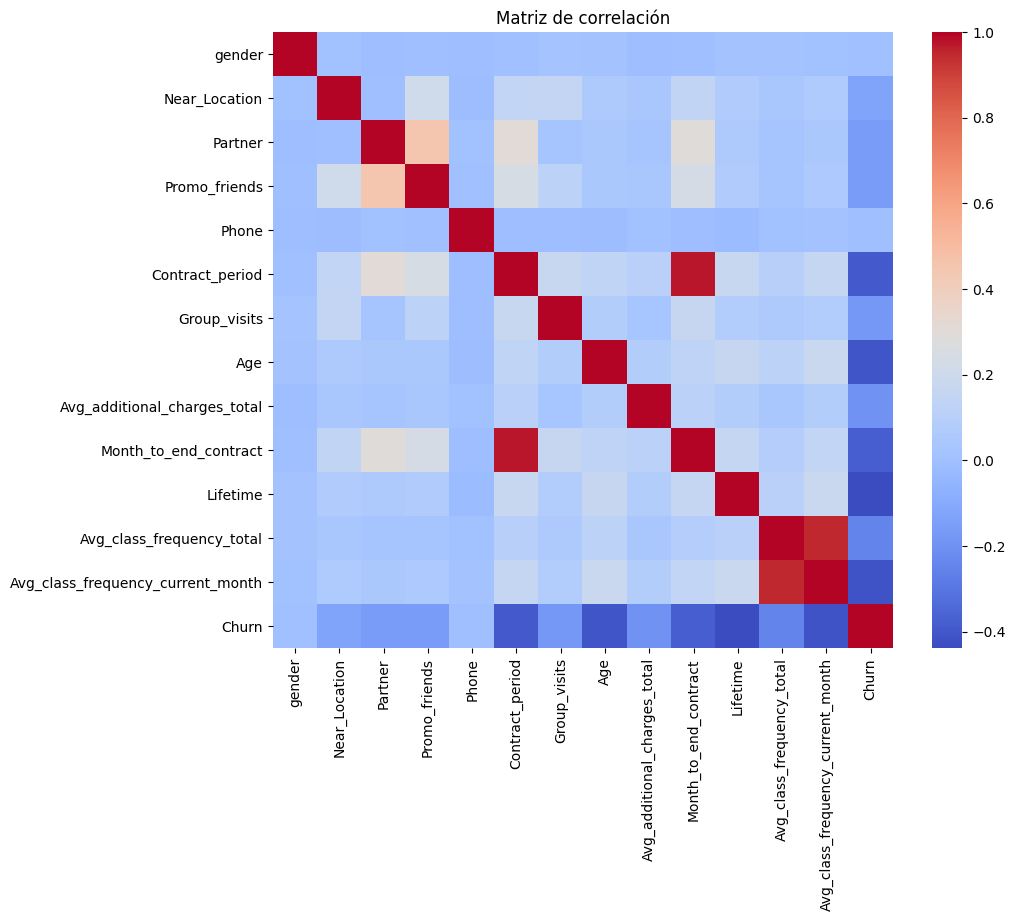

In [75]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()


### Resumen del EDA

- La variable objetivo `Churn` está desbalanceada: la mayoría de los clientes pertenecen a `Churn = 0` (no cancelan), mientras que alrededor de una cuarta parte pertenece a `Churn = 1`.
- Los clientes que **no cancelan** tienden a:
  - tener contratos más largos y más meses restantes (`Contract_period`, `Month_to_end_contract`);
  - llevar más tiempo en el gimnasio (`Lifetime`);
  - asistir con mayor frecuencia a clases (`Avg_class_frequency_total`, `Avg_class_frequency_current_month`);
  - gastar más en servicios adicionales (`Avg_additional_charges_total`);
  - participar más en clases grupales (`Group_visits`) y vivir/trabajar cerca del gimnasio (`Near_Location`).
- Las variables con **mayor correlación negativa** con `Churn` son `Lifetime`, `Avg_class_frequency_current_month`, `Age`, `Contract_period` y `Month_to_end_contract`, lo que indica que:
  - cuanto más tiempo lleve el cliente, más visitas haga y más largo sea el contrato, **menor** es la probabilidad de que cancele.
- `gender` y `Phone` prácticamente no se relacionan con `Churn`.


## Preparar modelo de clasificación

#### --> Preparación

In [87]:
target = 'Churn'
features = df.columns.drop(target)

X = df[features]
y = df[target]


X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=321, stratify=y
)

print("\n=== tamaños de los sets ===")
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)



=== tamaños de los sets ===
X_train: (3200, 14)
X_valid: (800, 14)
y_train: (3200,)
y_valid: (800,)


### Modelo 1: Regresión logística

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=321)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_valid)

acc_log = accuracy_score(y_valid, y_pred_log)
prec_log = precision_score(y_valid, y_pred_log)
rec_log = recall_score(y_valid, y_pred_log)

print("\n=== métricas LogisticRegression ===")
print("Accuracy:", acc_log)
print("Precision:", prec_log)
print("Recall:", rec_log)


### Modelo 2: Bosque aleatorio

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=321
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_valid)

acc_rf = accuracy_score(y_valid, y_pred_rf)
prec_rf = precision_score(y_valid, y_pred_rf)
rec_rf = recall_score(y_valid, y_pred_rf)

print("\n=== métricas RandomForest ===")
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)


### Comparar modelos

In [79]:
results = pd.DataFrame({
    'modelo': ['LogisticRegression', 'RandomForest'],
    'accuracy': [acc_log, acc_rf],
    'precision': [prec_log, prec_rf],
    'recall': [rec_log, rec_rf]
})

print("\n=== comparación de modelos ===")
results



=== comparación de modelos ===


,modelo,accuracy,precision,recall
0,LogisticRegression,0.91500,0.863636,0.806604
1,RandomForest,0.89625,0.834197,0.759434


### Comparación de modelos de clasificación

Se entrenaron dos modelos para predecir la cancelación (`Churn`):

- Regresión logística.
- Bosque aleatorio (`RandomForestClassifier`).

En el conjunto de validación se obtuvieron las siguientes métricas:

- **Regresión logística**  
  - Accuracy = 0.92  
  - Precision = 0.86  
  - Recall = 0.81  

- **Bosque aleatorio**  
  - Accuracy = 0.90  
  - Precision = 0.83  
  - Recall = 0.76  

La regresión logística muestra valores ligeramente superiores de *accuracy*, *precision* y *recall*.  
Dado que para el negocio es importante identificar la mayor cantidad posible de clientes que van a cancelar (maximizar el **recall**) sin aumentar demasiado los falsos positivos, se seleccionó la **regresión logística** como modelo principal para predecir el churn.


## Clústeres de usuarios

#### --> Preparación

In [80]:
# eliminar la columna objetivo para el clustering
features_clust = df.columns.drop('Churn')
X_clust = df[features_clust]


scaler = StandardScaler()
X_clust_sc = scaler.fit_transform(X_clust)

print("\n=== forma de X_clust ===")
print(X_clust.shape)

print("\n=== ejemplo de primeras filas estandarizadas ===")
print(X_clust_sc[:5])



=== forma de X_clust ===
(4000, 13)

=== ejemplo de primeras filas estandarizadas ===
[[ 0.97970588  0.42788074  1.02686062  1.49716101 -3.05985201  0.28989014
   1.19403206 -0.0565538  -1.37753121  0.16160501 -0.19332863 -1.91191971
  -1.67847198]
 [-1.0207145   0.42788074 -0.973842   -0.66793083  0.32681319  1.60882159
   1.19403206  0.55732732 -0.35021325  1.83194105  0.87368001  0.04517569
   0.1360137 ]
 [-1.0207145   0.42788074  1.02686062 -0.66793083  0.32681319 -0.8092194
  -0.83749845 -0.36349436 -0.1815923  -0.79287273 -0.46008079 -0.02049263
  -0.02901851]
 [-1.0207145   0.42788074  1.02686062  1.49716101  0.32681319  1.60882159
   1.19403206  1.17120844 -0.87472237  1.83194105 -0.46008079  1.36465509
   1.51045005]
 [ 0.97970588  0.42788074  1.02686062  1.49716101  0.32681319 -0.8092194
  -0.83749845 -0.97737548  0.5336998  -0.79287273 -0.19332863 -0.78707638
  -0.61454183]]


### Dendrograma

In [ ]:
linked = linkage(X_clust_sc, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Dendrograma de clientes Model Fitness')
plt.xlabel('Clientes')
plt.ylabel('Distancia')
plt.show()


### K-means con 5 clústeres

In [ ]:
km = KMeans(n_clusters=5, random_state=321)
clusters = km.fit_predict(X_clust_sc)

df['cluster'] = clusters

print("\n=== distribución de clientes por clúster ===")
print(df['cluster'].value_counts().sort_index())


### Perfil de cada clúster

In [83]:
cluster_profile = df.groupby('cluster').mean().T

print("\n=== medias de las características por clúster (transpuesta) ===")
cluster_profile



=== medias de las características por clúster (transpuesta) ===


cluster,0,1,2,3,4
gender,0.554259,0.488655,0.501478,0.523316,0.496063
Near_Location,0.978996,1.000000,0.960591,0.862694,0.000000
Partner,0.352392,0.352512,0.782266,0.471503,0.460630
Promo_friends,0.232205,0.238250,0.574384,0.305699,0.078740
Phone,1.000000,1.000000,1.000000,0.000000,1.000000
Contract_period,2.569428,1.965964,10.882759,4.777202,2.375984
Group_visits,0.471412,0.340357,0.540887,0.427461,0.218504
Age,30.098016,28.147488,29.979310,29.297927,28.486220
Avg_additional_charges_total,162.437671,130.319935,160.817799,144.208179,135.544499
Month_to_end_contract,2.368728,1.875203,9.944828,4.466321,2.222441


### Tasa de churn en cada clúster

In [84]:
churn_by_cluster = df.groupby('cluster')['Churn'].mean()

print("\n=== tasa de churn por clúster ===")
print(churn_by_cluster)



=== tasa de churn por clúster ===
cluster
0    0.071179
1    0.522690
2    0.027586
3    0.266839
4    0.440945
Name: Churn, dtype: float64


### Análisis de los clústeres de clientes

A partir del modelo de *clustering* K-means con 5 clústeres se identificaron los siguientes grupos de clientes:

---

### **Clúster 0 – Clientes locales frecuentes (bajo riesgo)**  
- Viven o trabajan casi siempre cerca del gimnasio (Near_Location muy alto).  
- Contratos de duración corta a media, con un Lifetime cercano a 5 meses.  
- Frecuencia de visitas y gasto adicional por encima de la media.  
- **Tasa de churn muy baja (7%).**  
→ Son clientes activos y estables, que aunque no tengan contratos largos, mantienen un uso frecuente del servicio.

---

### **Clúster 1 – Clientes de prueba o de corto plazo (alto riesgo)**  
- Contratos muy cortos y Lifetime reducido.  
- Baja frecuencia de visitas y bajo gasto en servicios adicionales.  
- **Tasa de churn extremadamente alta (52%).**  
→ Son usuarios que prueban el gimnasio por poco tiempo y suelen abandonarlo rápidamente.

---

### **Clúster 2 – Clientes corporativos y muy leales (muy bajo riesgo)**  
- Alta proporción de clientes provenientes de empresas asociadas y de promociones de amigos.  
- Contratos largos, muchos meses restantes y alta frecuencia de asistencia.  
- Gasto adicional elevado.  
- **Tasa de churn muy baja (3%).**  
→ Es el segmento más valioso: clientes comprometidos, con alta retención y buen nivel de monetización.

---

### **Clúster 3 – Clientes activos de contrato medio (riesgo medio)**  
- Contratos intermedios y un Lifetime moderado.  
- Frecuencia de visitas razonable y gasto adicional moderado.  
- **Tasa de churn media (27%).**  
→ Grupo heterogéneo que puede ser consolidado con acciones de retención específicas.

---

### **Clúster 4 – Clientes lejanos o poco vinculados (alto riesgo)**  
- Menor proporción de clientes que viven cerca del gimnasio.  
- Contratos relativamente cortos y Lifetime reducido.  
- Frecuencias de visita y gasto adicional menores que en otros grupos.  
- **Tasa de churn alta (44%).**  
→ Son clientes con menor compromiso y mayor probabilidad de abandonar.

---

### **Resumen general**

- Los clústeres **1 y 4** representan los segmentos de **mayor riesgo de abandono** y deben ser priorizados en estrategias de retención.  
- Los clústeres **0 y 2** contienen a los clientes **más leales**, siendo el clúster 2 el de más alto valor por su combinación de retención, uso y gasto.  
- El clúster **3** es un grupo intermedio que puede inclinarse hacia la lealtad o el abandono dependiendo de la experiencia y los incentivos que reciba.


## Conclusiones generales del análisis

El análisis realizado permitió identificar los factores más relevantes asociados a la cancelación de clientes en Model Fitness.

A partir del EDA se observaron patrones claros: los clientes con contratos más largos, mayor frecuencia de visitas, mayor gasto en servicios adicionales y un Lifetime más alto presentan una probabilidad significativamente menor de cancelar. En cambio, los usuarios con baja actividad, contratos cortos y poco tiempo en el gimnasio son los más propensos a abandonarlo.

El modelo de clasificación confirmó estas tendencias. La **regresión logística** fue el modelo con mejor desempeño y permite predecir la cancelación con métricas sólidas, especialmente en términos de recall (identificación de clientes en riesgo).

El análisis de clústeres reveló cinco segmentos de clientes con comportamientos distintos. Algunos grupos muestran una retención muy alta (clúster 2), mientras que otros presentan tasas elevadas de churn (clústeres 1 y 4). Esto permite diseñar estrategias más enfocadas para cada tipo de usuario.


## Recomendaciones para mejorar la retención de clientes

A partir del análisis realizado, se proponen las siguientes acciones:

---

### **1. Enfocar estrategias de retención en los clústeres de mayor riesgo**
Los clientes de los clústeres **1 y 4** presentan tasas de churn superiores al 40%.  
Acciones sugeridas:
- Sesiones de onboarding personalizadas durante el primer mes.
- Promociones para aumentar la frecuencia inicial (primeras 4 semanas).
- Recordatorios automáticos y comunicación proactiva cuando disminuye su asistencia.

---

### **2. Incentivar la extensión del contrato en clientes nuevos**
Los usuarios con contratos **cortos** y bajo Lifetime son quienes más abandonan.  
Recomendaciones:
- Descuentos por renovación anticipada.
- Bonos por extender contrato a 3, 6 o 12 meses.
- Programas “compromiso + recompensa” (ej. regalar un mes por X semanas de asistencia).

---

### **3. Aumentar la participación en clases grupales**
La asistencia a clases grupales se asocia a menor churn en varios clústeres.  
Ideas:
- Pruebas gratuitas para nuevas clases.
- Retos semanales con métricas de asistencia.
- Packs ilimitados de clases por un precio reducido durante el primer mes.

---

### **4. Mantener y potenciar la relación con clientes leales**
Los clústeres **0 y 2** incluyen usuarios con baja probabilidad de cancelación.  
Para mantenerlos:
- Programas de fidelidad.
- Beneficios exclusivos por antigüedad.
- Ofertas especiales en servicios adicionales, donde ya muestran alto gasto.

---

Estas acciones permitirían abordar los segmentos críticos, reforzar las dinámicas de uso más saludables y, en general, mejorar la retención mensual del gimnasio.


## Conclusiones generales del proyecto

- Nivel general: en conjunto, tu trabajo contiene elementos sólidos que apuntan a un manejo intermedio: cubres todo el flujo requerido (EDA, split, entreno de modelos, evaluación y clustering) y las recomendaciones son coherentes con los resultados. ✅🚀  
- Fortalezas principales:  
  - EDA bien estructurado y visualizaciones claras que respaldan las conclusiones. 📊  
  - Entrenamiento y comparación de modelos con métricas relevantes (accuracy, precision, recall). 🧠  
  - Clustering bien ejecutado (estandarización, dendrograma, KMeans y perfilado útil de segmentos). 🧩
- Áreas que he observado como oportunidad de mejora:  
  - Toma en cuenta que faltó mostrar de forma explícita la importancia de las variables (coeficientes de la regresión logística o feature_importances_ del Random Forest), lo cual ayudaría a justificar mejor el modelo y priorizar acciones. 🔍  
  - Sería bueno reforzar la visualización de las distribuciones por cluster (boxplots / histogramas por cluster) para complementar la tabla de medias. 📈  
  - Siempre asegurate que no existas filtraciones de la variable objetivo y considera análisis de multicolinealidad entre features correlacionadas (esto me pasaba comúnmente  a mí cuando iniciaba en el Data Science!!!). 🔁
- Con estas recomendaciones tu proyecto pasará a un nivel MASTER rápidamente. ¡Vas muy bien, sigue así! 💪